In [ ]:
pip install pandas
pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 45.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

### CHECKING THE LIST OF PROJECT FROM MIN CITY AND THE SHEETS FROM CAIXA

In [5]:
f_merge = "/home/coder/chp2/merge_final_clean.xlsx"   ## combination of table from 2017 and 2024 
f_tab   = "/home/coder/chp2/Tab2026DADOS_BÁSICOS.xlsx" ## table from 2025 pendencies from CAIXA
df1 = pd.read_excel(f_merge, dtype=str)
df2 = pd.read_excel(f_tab, dtype=str)

In [6]:
## cleaning columns to match them 
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print("Cols df1:", df1.columns.tolist())
print("Cols df2:", df2.columns.tolist())

# -----------------------
# Helper: limpar contrato (remove zeros à esquerda)
# -----------------------
def clean_contract(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    # remove tudo que não é dígito (se tiver 'R$' etc não deve, mas fica robusto)
    s = s.str.replace(r"\D+", "", regex=True)
    # remove zeros à esquerda
    s = s.str.lstrip("0")
    return s

def clean_uf(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.upper()

Cols df1: ['IBGE-7', 'UF', 'Município', 'municipio', 'contrato', 'source', 'Pac 1 ou Pac 2', 'Proponente', 'Programa', 'Tipo', 'Eixo Habitação', 'Origem Recurso', 'Classificação Funcional-Programática', 'Nome da Intervenção', 'Local Intervenção', 'Modalidade', 'Tomador', 'andamento_2017', 'sit_obra_2017', 'sit_obra_2025', 'status_contr_2025', 'status_contr_2027', 'perc_done_2017', 'data_ass_2017', 'effec_beg_2025', 'prev_end_2025', 'liberado_2017', 'repasse_2017', 'Contrapartida', 'valor_inv_2017', 'valor_repasse_2025', 'valor_contrap_2025', 'valor_inv_total_2025', 'liberato_dez2025', 'Famílias Beneficiadas', 'Fonte', 'selec_year_2017', 'Modalidade_df2']
Cols df2: ['COD PROJETO', 'Ident_Externo_Código', 'ÁREA', 'ORIGEM DO RECURSO', 'PROGRAMA', 'SETOR', 'UF', 'SR', 'MUNICÍPIO-TOMADOR', 'DT_ASSINATURA', 'DataVigencia', 'SITUAÇÃO', 'GIDUR-REDUR', 'NOME PADRINHO', 'TELEFONE PADRINHO', 'CLASSE', 'ANO DA SELEÇÃO', 'DATA DA VÍDEO CONFERÊNCIA', 'Empreendimento', 'Nome_Destaque_Empreend', 'Obje

In [7]:
# -----------------------
# Clean keys
# -----------------------
df1["_contrato_clean"] = clean_contract(df1["contrato"])
df1["_uf_clean"] = clean_uf(df1["UF"])

df2["_contrato_clean"] = clean_contract(df2["COD PROJETO"])  # remove zero inicial aqui
df2["_uf_clean"] = clean_uf(df2["UF"])

In [8]:
# -----------------------
# Criar chave e checar existência
# -----------------------
df1["_key"] = df1["_contrato_clean"] + "|" + df1["_uf_clean"]
df2["_key"] = df2["_contrato_clean"] + "|" + df2["_uf_clean"]

In [9]:
# join só para checar presença
check = df1.merge(
    df2[["_key"]].drop_duplicates(),
    on="_key",
    how="left",
    indicator=True
)

In [10]:
len(df1) #1776
len(df2) #12538
len(check) #1776

1776

In [11]:
total = len(df1)
matched = (check["_merge"] == "both").sum()
missing = (check["_merge"] == "left_only").sum()

print("\n=== CHECK EXISTÊNCIA (df1 em df2) ===")
print("Total linhas df1 (com chave válida):", total)
print("Encontradas em df2:", matched)
print("Faltando em df2:", missing)
print("Taxa match:", round(matched / total * 100, 2), "%")


=== CHECK EXISTÊNCIA (df1 em df2) ===
Total linhas df1 (com chave válida): 1776
Encontradas em df2: 1624
Faltando em df2: 152
Taxa match: 91.44 %


In [12]:
missing_rows = check.loc[check["_merge"] == "left_only"].copy()
missing_rows

out = "all_merge_Tab2026_missing.xlsx"
missing_rows.to_excel(out, index=False)

In [13]:
df2_pref = df2.copy()

# renomeia todas as colunas do df2, exceto a chave
df2_pref = df2_pref.rename(columns={c: f"tab26_{c}" for c in df2_pref.columns if c != "_key"})

df_merged_check = df1.merge(
    df2_pref,
    on="_key",
    how="left",
    indicator=True
)

print(df_merged_check["_merge"].value_counts())

_merge
both          1624
left_only      152
right_only       0
Name: count, dtype: int64


In [14]:
out = "all_merge_Tab2026.xlsx"
df_merged_check.to_excel(out, index=False)

### GETTING INFORMATION FROM CAIXA - only the projects in both df

In [21]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 42.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 99.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 92.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

#### type of investment

In [16]:
opc_itens_path = Path("/home/coder/chp2/opc_itens_investimentos.xlsx")
tab_itens_path = Path("/home/coder/chp2/tab_itens_investimentos.xlsx")
opc = pd.read_excel(opc_itens_path, dtype=str)
tab = pd.read_excel(tab_itens_path, dtype=str)

In [17]:
df_proj = (
    df_merged_check[["IBGE-7", "tab26_COD PROJETO"]]
    .dropna(subset=["tab26_COD PROJETO"])   # remove linhas sem projeto
    .drop_duplicates()                     # remove duplicados
    .sort_values(["IBGE-7", "tab26_COD PROJETO"])
)


In [18]:
for df in [df_proj, tab, opc]:
    df.columns = df.columns.str.strip()

df_proj["tab26_COD PROJETO"] = df_proj["tab26_COD PROJETO"].astype(str).str.strip()
tab["pt"] = tab["pt"].astype(str).str.strip()
tab["cod_item_investimento"] = tab["cod_item_investimento"].astype(str).str.strip()
opc["cod_item_investimento"] = opc["cod_item_investimento"].astype(str).str.strip()

In [19]:
# --------------------------------------------------
# 1) Filtrar tab_itens apenas projetos existentes
# --------------------------------------------------
tab_filtrado = tab[
    tab["pt"].isin(df_proj["tab26_COD PROJETO"])
].copy()

# --------------------------------------------------
# 2) Adicionar descrição do item and IBGE municipality number
# --------------------------------------------------
tab_final = tab_filtrado.merge(
    opc[["cod_item_investimento", "dsc_item_investimento"]],
    on="cod_item_investimento",
    how="left"
)

tab_final = tab_final.merge(
    df_proj[["tab26_COD PROJETO", "IBGE-7"]],
    left_on="pt",
    right_on="tab26_COD PROJETO",
    how="left"
)
tab_final = tab_final.drop(columns=["tab26_COD PROJETO"], errors="ignore")

In [20]:
# visualizar
print(tab_final.head())

          pt cod_item_investimento valor_item_investimento  \
0  023342877                   400                35763.41   
1  023342877                   126                   27000   
2  023342877                   019              1344420.15   
3  024988664                   400                28993.95   
4  024988664                   126                   12100   

                      dsc_item_investimento   IBGE-7  
0  RENDIMENTOS                               4104907  
1  TRABALHO SOCIAL                           4104907  
2  CONSTRUCAO DE UNIDADES HABITACIONAIS      4104907  
3  RENDIMENTOS                               4101606  
4  TRABALHO SOCIAL                           4101606  


In [21]:
tab_final["valor_item_investimento_num"] = pd.to_numeric(tab_final["valor_item_investimento"])

In [22]:
dist = (
    tab_final.dropna(subset=["dsc_item_investimento"])
      .groupby("dsc_item_investimento", as_index=False)
      .agg(
          n_linhas=("pt", "size"),
          n_projetos=("pt", pd.Series.nunique),
          valor_total=("valor_item_investimento_num", "sum"),
          valor_medio=("valor_item_investimento_num", "mean"),
      )
      .sort_values(["n_projetos", "valor_total"], ascending=False)
)
dist["valor_total"] = pd.to_numeric(dist["valor_total"], errors="coerce")
dist["valor_medio"] = pd.to_numeric(dist["valor_medio"], errors="coerce")
dist["valor_total"] = dist["valor_total"] / 1_000_000
dist["valor_medio"] = dist["valor_medio"] / 1_000_000

In [23]:
# visualizar
print(dist.head())

                       dsc_item_investimento  n_linhas  n_projetos  \
63  RENDIMENTOS                                   1114        1114   
73  TRABALHO SOCIAL                               1048        1048   
16  CONSTRUCAO DE UNIDADES HABITACIONAIS           966         966   
60  REGULARIZACAO FUNDIARIA                        362         362   
69  SERVICOS PRELIMINARES                          330         330   

    valor_total  valor_medio  
63   661.732897     0.594015  
73   684.844147     0.653477  
16  2914.859181     3.017453  
60   268.558198     0.741873  
69   506.031560     1.533429  


In [24]:
pip install Jinja2

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
def fmt_money_m(x):
    if pd.isna(x):
        return ""
    return f"{x:,.2f}"

dist["valor_total"] = dist["valor_total"].map(fmt_money_m)
dist["valor_medio"] = dist["valor_medio"].map(fmt_money_m)

latex_table = dist.rename(columns={
    "dsc_item_investimento": "Item de investimento",
    "n_linhas": "N linhas",
    "n_projetos": "N projetos",
    "valor_total": "Valor total (R$ mi)",
    "valor_medio": "Valor médio (R$ mi)",
}).to_latex(index=False, escape=True)

print(latex_table)

\begin{tabular}{lrrll}
\toprule
Item de investimento & N linhas & N projetos & Valor total (R\$ mi) & Valor médio (R\$ mi) \\
\midrule
RENDIMENTOS                              & 1114 & 1114 & 661.73 & 0.59 \\
TRABALHO SOCIAL                          & 1048 & 1048 & 684.84 & 0.65 \\
CONSTRUCAO DE UNIDADES HABITACIONAIS     & 966 & 966 & 2,914.86 & 3.02 \\
REGULARIZACAO FUNDIARIA                  & 362 & 362 & 268.56 & 0.74 \\
SERVICOS PRELIMINARES                    & 330 & 330 & 506.03 & 1.53 \\
EQUIPAMENTOS COMUNITARIOS                & 327 & 327 & 640.61 & 1.96 \\
PAVIMENTACAO                             & 316 & 316 & 542.82 & 1.72 \\
PROJETOS                                 & 310 & 310 & 244.55 & 0.79 \\
DRENAGEM DE AGUAS PLUVIAIS               & 275 & 275 & 1,076.73 & 3.92 \\
ABASTECIMENTO DE AGUA                    & 263 & 263 & 675.12 & 2.57 \\
ESGOTAMENTO SANITARIO                    & 241 & 241 & 884.60 & 3.67 \\
TERRAPLENAGEM                            & 241 & 241 & 588.91 & 2

NameError: name 'out_plot_png' is not defined

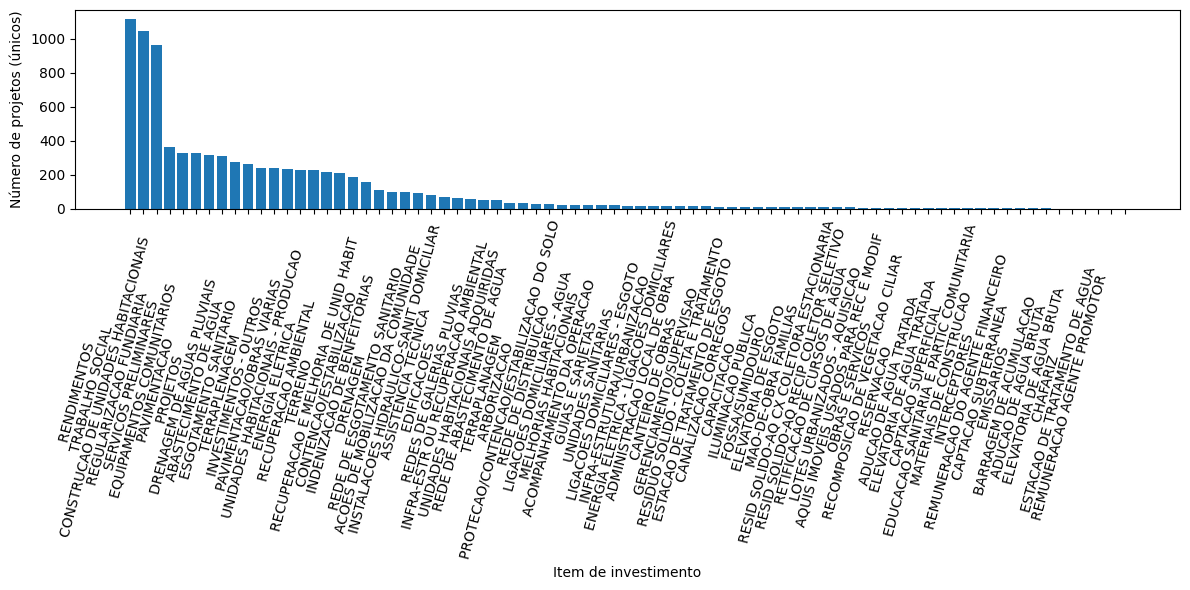

In [ ]:
plot_df = dist.head(20).copy()

plt.figure(figsize=(12, 6))
plt.bar(dist["dsc_item_investimento"], dist["n_projetos"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("Item de investimento")
plt.ylabel("Número de projetos (únicos)")
plt.tight_layout()
#plt.savefig(out_plot_png, dpi=200)
plt.close()

In [30]:
## Distribution of cathegories: same project can have +1 cathegory and receive money for it
# número de categorias distintas por projeto
cats_per_project = (
    tab_final.groupby("pt")["dsc_item_investimento"]
    .nunique()
    .reset_index(name="n_categories")
)
cats_per_project

,pt,n_categories
0,017543314,1
1,021575350,13
2,021859044,11
3,021859159,11
4,021859263,9
...,...,...
1619,044519232,3
1620,044520928,3
1621,044522417,3
1622,044522522,4


In [31]:
# distribuição
dist_categories = (
    cats_per_project["n_categories"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dist_categories.columns = ["n_categories", "n_projects"]

print(dist_categories)

    n_categories  n_projects
0              1         154
1              2         375
2              3         337
3              4         153
4              5          63
5              6          60
6              7          65
7              8          66
8              9          60
9             10          58
10            11          47
11            12          38
12            13          30
13            14          25
14            15          27
15            16          29
16            17          22
17            18          10
18            19           4
19            20           1


In [32]:
dist_categories["share_projects"] = (
    dist_categories["n_projects"] /
    dist_categories["n_projects"].sum()
)

print(dist_categories)

    n_categories  n_projects  share_projects
0              1         154        0.094828
1              2         375        0.230911
2              3         337        0.207512
3              4         153        0.094212
4              5          63        0.038793
5              6          60        0.036946
6              7          65        0.040025
7              8          66        0.040640
8              9          60        0.036946
9             10          58        0.035714
10            11          47        0.028941
11            12          38        0.023399
12            13          30        0.018473
13            14          25        0.015394
14            15          27        0.016626
15            16          29        0.017857
16            17          22        0.013547
17            18          10        0.006158
18            19           4        0.002463
19            20           1        0.000616


In [33]:
# total por projeto
total_project_value = (
    tab_final.groupby("pt")["valor_item_investimento_num"]
    .sum()
    .reset_index(name="project_total")
)

# juntar
tab_share = tab_final.merge(total_project_value, on="pt", how="left")

In [34]:
tab_share["category_share"] = (
    tab_share["valor_item_investimento_num"] /
    tab_share["project_total"]
)
tab_share

,pt,cod_item_investimento,valor_item_investimento,dsc_item_investimento,IBGE-7,valor_item_investimento_num,project_total,category_share
0,023342877,400,35763.41,RENDIMENTOS,4104907,35763.41,1407183.56,0.025415
1,023342877,126,27000,TRABALHO SOCIAL,4104907,27000.00,1407183.56,0.019187
2,023342877,019,1344420.15,CONSTRUCAO DE UNIDADES HABITACIONAIS,4104907,1344420.15,1407183.56,0.955398
3,024988664,400,28993.95,RENDIMENTOS,4101606,28993.95,759600.22,0.038170
4,024988664,126,12100,TRABALHO SOCIAL,4101606,12100.00,759600.22,0.015929
...,...,...,...,...,...,...,...,...
8532,035240960,126,106666,TRABALHO SOCIAL,4305207,106666.00,1563187.76,0.068236
8533,035240960,219,127187.16,DRENAGEM,4305207,127187.16,1563187.76,0.081364
8534,035240960,127,481480.84,INVESTIMENTOS - OUTROS,4305207,481480.84,1563187.76,0.308012
8535,035240960,138,43012.63,RECUPERACAO AMBIENTAL,4305207,43012.63,1563187.76,0.027516


In [35]:
#Em média, quando um projeto tem essa categoria, qual fração do orçamento total ela representa?
mean_share_by_category = (
    tab_share.groupby("dsc_item_investimento")["category_share"]
    .mean()
    .reset_index()
    .sort_values("category_share", ascending=False)
)

print(mean_share_by_category.head(20))

                       dsc_item_investimento  category_share
20  EDIFICACOES                                     0.871740
44  LOTES URBANIZADOS - AQUISICAO                   0.851740
48  OBRAS E SERVICOS                                0.839108
16  CONSTRUCAO DE UNIDADES HABITACIONAIS            0.810449
74  UNIDADES HABITACIONAIS - PRODUCAO               0.493473
14  CAPTACAO SUPERFICIAL                            0.469283
75  UNIDADES HABITACIONAIS ADQUIRIDAS               0.435469
37  INFRA-ESTR OU RECUPERACAO AMBIENTAL             0.342346
10  CANALIZACAO CORREGOS                            0.335538
68  RETIFICACAO DE CURSOS DE AGUA                   0.311964
41  INVESTIMENTOS - OUTROS                          0.302129
46  MATERIAIS DE CONSTRUCAO                         0.284302
23  ELEVATORIA DE AGUA TRATADA                      0.265969
49  PAVIMENTACAO                                    0.243818
9   BARRAGEM DE ACUMULACAO                          0.233258
50  PAVIMENTACAO/OBRAS V

In [36]:
# total de projetos únicos
total_projects = tab_share["pt"].nunique()

# top 20 categorias pelo share médio
top20 = mean_share_by_category.head(20)["dsc_item_investimento"]

# calcular percentual de projetos que têm cada categoria
top20_presence = (
    tab_share[tab_share["dsc_item_investimento"].isin(top20)]
    .groupby("dsc_item_investimento")["pt"]
    .nunique()
    .reset_index(name="n_projects_with_category")
)

# calcular percentual
top20_presence["share_of_projects"] = (
    top20_presence["n_projects_with_category"] / total_projects
)

# manter só categoria + percentual
top20_presence = (
    top20_presence[["dsc_item_investimento", "share_of_projects"]]
    .sort_values("share_of_projects", ascending=False)
    .reset_index(drop=True)
)
print(top20_presence.head(20))

                       dsc_item_investimento  share_of_projects
0   CONSTRUCAO DE UNIDADES HABITACIONAIS               0.594828
1   PAVIMENTACAO                                       0.194581
2   INVESTIMENTOS - OUTROS                             0.142857
3   PAVIMENTACAO/OBRAS VIARIAS                         0.140394
4   UNIDADES HABITACIONAIS - PRODUCAO                  0.139778
5   RECUPERACAO E MELHORIA DE UNID HABIT               0.097291
6   EDIFICACOES                                        0.035099
7   INFRA-ESTR OU RECUPERACAO AMBIENTAL                0.030788
8   UNIDADES HABITACIONAIS ADQUIRIDAS                  0.021552
9   INFRA-ESTRUTURA/URBANIZACAO                        0.010468
10  ESTACAO DE TRATAMENTO DE ESGOTO                    0.007389
11  CANALIZACAO CORREGOS                               0.006158
12  RETIFICACAO DE CURSOS DE AGUA                      0.004310
13  LOTES URBANIZADOS - AQUISICAO                      0.004310
14  OBRAS E SERVICOS                    

#### calendar of investments

In [37]:
# garantir que category_share é numérico
tab_share["category_share"] = pd.to_numeric(tab_share["category_share"], errors="coerce")

# pegar a linha com maior share dentro de cada projeto
df_main_activity = (
    tab_share.sort_values("category_share", ascending=False)
    .drop_duplicates(subset="pt")
    [["pt", "IBGE-7", "dsc_item_investimento", "category_share"]]
    .reset_index(drop=True)
)

In [38]:
tab_month = Path("/home/coder/chp2/Tab_Desbloqueado_Mensal.xlsx")
month = pd.read_excel(tab_month, dtype=str)
month.columns = month.columns.str.strip()

proj_cat = df_main_activity[["pt", "dsc_item_investimento"]].copy()
VALUE_COL = "ValorDesbloqueado_VE"   # ou "ValorDesblorqueado_CP" / "ValorDesblorqueado_VI"
MONTH_COL = "MesLIB"
YEAR_COL = "AnoLIB"
PROJ_COL  = "COD PROJETO"

month[PROJ_COL] = month[PROJ_COL].astype(str).str.strip()
month[MONTH_COL] = month[MONTH_COL].astype(str).str.strip()
month[YEAR_COL] = pd.to_numeric(month[YEAR_COL], errors="coerce")
v = month[VALUE_COL].astype(str).str.strip()
v = v.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
month["_valor_num"] = pd.to_numeric(v, errors="coerce").fillna(0.0)

# criar uma coluna de data (YYYY-MM-01) para série temporal
month["date"] = pd.to_datetime(
    dict(year=month[YEAR_COL], month=month[MONTH_COL], day=1),
    errors="coerce"
)

In [147]:
# =========================
# 1) Somar desbloqueio mensal por projeto
# =========================
proj_month = (
    month.dropna(subset=["date"])
         .groupby([PROJ_COL, "date"], as_index=False)["_valor_num"]
         .sum()
         .rename(columns={PROJ_COL: "pt", "_valor_num": "valor_mes"})
)
proj_month

,pt,date,valor_mes
0,012865286,2004-12-01,45000
1,012865286,2005-05-01,14031496
2,012865286,2005-09-01,8167096
3,012865286,2005-12-01,10561596
4,012865286,2006-08-01,18593581
...,...,...,...
65529,035148916,2013-11-01,40275
65530,035148916,2014-08-01,6947138
65531,035148916,2014-10-01,27833657
65532,035149159,2012-12-01,8880675


In [148]:
# =========================
# 2) Total desbloqueado por projeto e % mensal
# =========================
tot = proj_month.groupby("pt", as_index=False)["valor_mes"].sum().rename(columns={"valor_mes": "total_proj"})
proj_month = proj_month.merge(tot, on="pt", how="left")

proj_month["share_mes"] = np.where(
    proj_month["total_proj"] > 0,
    proj_month["valor_mes"] / proj_month["total_proj"],
    np.nan
)


In [150]:
proj_cat

,pt,dsc_item_investimento
0,023345843,CONSTRUCAO DE UNIDADES HABITACIONAIS
1,023327197,PAVIMENTACAO
2,028716984,CONSTRUCAO DE UNIDADES HABITACIONAIS
3,035227229,CONSTRUCAO DE UNIDADES HABITACIONAIS
4,032265180,CONSTRUCAO DE UNIDADES HABITACIONAIS
...,...,...
1619,023574905,PAVIMENTACAO
1620,035274640,UNIDADES HABITACIONAIS - PRODUCAO
1621,025114750,DRENAGEM
1622,022260608,DRENAGEM DE AGUAS PLUVIAIS


In [149]:
# =========================
# 3) Juntar categoria do projeto
# =========================
proj_month = proj_month.merge(proj_cat, on="pt", how="left")
proj_month

,pt,date,valor_mes,total_proj,share_mes,dsc_item_investimento
0,012865286,2004-12-01,45000,85545000,0.000526,NaN
1,012865286,2005-05-01,14031496,85545000,0.164025,NaN
2,012865286,2005-09-01,8167096,85545000,0.095471,NaN
3,012865286,2005-12-01,10561596,85545000,0.123462,NaN
4,012865286,2006-08-01,18593581,85545000,0.217354,NaN
...,...,...,...,...,...,...
65529,035148916,2013-11-01,40275,43216382,0.000932,NaN
65530,035148916,2014-08-01,6947138,43216382,0.160752,NaN
65531,035148916,2014-10-01,27833657,43216382,0.644053,NaN
65532,035149159,2012-12-01,8880675,16713804,0.531338,NaN


In [ ]:

cal_ts = (
    proj_month.dropna(subset=["dsc_item_investimento"])
              .groupby(["dsc_item_investimento", "date"], as_index=False)
              .agg(
                  mean_share=("share_mes", "mean"),           # média do % mensal
                  mean_value=("valor_mes", "mean"),           # média do valor mensal (opcional)
                  total_value=("valor_mes", "sum"),           # total liberado na categoria nesse mês (opcional)
                  n_projects=("pt", pd.Series.nunique),
              )
              .sort_values(["dsc_item_investimento", "date"])
)

print(cal_ts.head(20))   ## put the category of the intervention as the one that has % of inv according to the other df

                       dsc_item_investimento       date  mean_share  \
0   ABASTECIMENTO DE AGUA                    2008-09-01    0.024611   
1   ABASTECIMENTO DE AGUA                    2008-10-01    0.050527   
2   ABASTECIMENTO DE AGUA                    2008-11-01    0.009302   
3   ABASTECIMENTO DE AGUA                    2008-12-01    0.089231   
4   ABASTECIMENTO DE AGUA                    2009-01-01    0.023629   
5   ABASTECIMENTO DE AGUA                    2009-02-01    0.060294   
6   ABASTECIMENTO DE AGUA                    2009-03-01    0.063334   
7   ABASTECIMENTO DE AGUA                    2009-04-01    0.046870   
8   ABASTECIMENTO DE AGUA                    2009-05-01    0.044099   
9   ABASTECIMENTO DE AGUA                    2009-06-01    0.031873   
10  ABASTECIMENTO DE AGUA                    2009-07-01    0.016995   
11  ABASTECIMENTO DE AGUA                    2009-08-01    0.051221   
12  ABASTECIMENTO DE AGUA                    2009-09-01    0.035122   
13  AB

In [145]:
proj_month

,pt,date,valor_mes,total_proj,share_mes,dsc_item_investimento
0,012865286,2004-12-01,45000,85545000,0.000526,NaN
1,012865286,2005-05-01,14031496,85545000,0.164025,NaN
2,012865286,2005-09-01,8167096,85545000,0.095471,NaN
3,012865286,2005-12-01,10561596,85545000,0.123462,NaN
4,012865286,2006-08-01,18593581,85545000,0.217354,NaN
...,...,...,...,...,...,...
65529,035148916,2013-11-01,40275,43216382,0.000932,NaN
65530,035148916,2014-08-01,6947138,43216382,0.160752,NaN
65531,035148916,2014-10-01,27833657,43216382,0.644053,NaN
65532,035149159,2012-12-01,8880675,16713804,0.531338,NaN


###### trying by looking at the % of each type of interveniton, per month

In [102]:
cal_ts_pivot = cal_ts.pivot(index="date", columns="dsc_item_investimento", values="mean_share").sort_index()
cal_ts_pivot

dsc_item_investimento,ABASTECIMENTO DE AGUA,ACOES DE MOBILIZACAO DA COMUNIDADE,ACOMPANHAMENTO DA OPERACAO,ARBORIZACAO,ASSISTENCIA TECNICA,CANALIZACAO CORREGOS,CAPTACAO SUPERFICIAL,CONSTRUCAO DE UNIDADES HABITACIONAIS,CONTENCAO/ESTABILIZACAO,DRENAGEM,...,REGULARIZACAO FUNDIARIA,RENDIMENTOS,RETIFICACAO DE CURSOS DE AGUA,SERVICOS PRELIMINARES,TERRAPLANAGEM,TERRAPLENAGEM,TERRENO,TRABALHO SOCIAL,UNIDADES HABITACIONAIS - PRODUCAO,UNIDADES HABITACIONAIS ADQUIRIDAS
date,,,,,,,,,,,,,,,,,,,,,
2003-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085477,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
2005-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.044758,NaN
2006-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007163,NaN
2006-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016681,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024056,0.030075,NaN,...,NaN,0.107778,0.006122,NaN,NaN,0.007227,NaN,NaN,0.007999,NaN
2025-11-01,0.000262,NaN,NaN,NaN,NaN,NaN,NaN,0.007784,NaN,NaN,...,NaN,NaN,0.000121,NaN,NaN,0.003177,NaN,NaN,0.004312,NaN
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017815,NaN,NaN,...,NaN,0.007599,NaN,NaN,0.003965,0.007870,0.010507,NaN,0.007880,NaN


In [103]:
# Print only column names
print(cal_ts_pivot.columns.tolist())

['ABASTECIMENTO DE AGUA                   ', 'ACOES DE MOBILIZACAO DA COMUNIDADE      ', 'ACOMPANHAMENTO DA OPERACAO              ', 'ARBORIZACAO                             ', 'ASSISTENCIA TECNICA                     ', 'CANALIZACAO CORREGOS                    ', 'CAPTACAO SUPERFICIAL                    ', 'CONSTRUCAO DE UNIDADES HABITACIONAIS    ', 'CONTENCAO/ESTABILIZACAO                 ', 'DRENAGEM                                ', 'DRENAGEM DE AGUAS PLUVIAIS              ', 'EDIFICACOES                             ', 'ELEVATORIA DE AGUA TRATADA              ', 'EQUIPAMENTOS COMUNITARIOS               ', 'ESGOTAMENTO SANITARIO                   ', 'FOSSA/SUMIDOURO                         ', 'GUIAS E SARJETAS                        ', 'INDENIZACAO DE BENFEITORIAS             ', 'INFRA-ESTR OU RECUPERACAO AMBIENTAL     ', 'INFRA-ESTRUTURA/URBANIZACAO             ', 'INVESTIMENTOS - OUTROS                  ', 'LOTES URBANIZADOS - AQUISICAO           ', 'MATERIAIS DE CONSTRUCAO       

In [104]:
rename_dict = {
    "ABASTECIMENTO DE AGUA                   ": "Water Supply",
    "ACOES DE MOBILIZACAO DA COMUNIDADE      ": "Community Mobilization Actions",
    "ACOMPANHAMENTO DA OPERACAO              ": "Operation Monitoring",
    "ARBORIZACAO                             ": "Afforestation",
    "ASSISTENCIA TECNICA                     ": "Technical Assistance",
    "CANALIZACAO CORREGOS                    ": "Stream Channelization",
    "CAPTACAO SUPERFICIAL                    ": "Surface Water Intake",
    "CONSTRUCAO DE UNIDADES HABITACIONAIS    ": "Construction of Housing Units",
    "CONTENCAO/ESTABILIZACAO                 ": "Slope Stabilization / Retaining Works",
    "DRENAGEM                                ": "Drainage",
    "DRENAGEM DE AGUAS PLUVIAIS              ": "Stormwater Drainage",
    "EDIFICACOES                             ": "Buildings",
    "ELEVATORIA DE AGUA TRATADA              ": "Treated Water Pumping Station",
    "EQUIPAMENTOS COMUNITARIOS               ": "Community Facilities",
    "ESGOTAMENTO SANITARIO                   ": "Sewage System",
    "FOSSA/SUMIDOURO                         ": "Septic Tank / Absorption Pit",
    "GUIAS E SARJETAS                        ": "Curbs and Gutters",
    "INDENIZACAO DE BENFEITORIAS             ": "Compensation for Improvements",
    "INFRA-ESTR OU RECUPERACAO AMBIENTAL     ": "Infrastructure or Environmental Restoration",
    "INFRA-ESTRUTURA/URBANIZACAO             ": "Infrastructure / Urbanization",
    "INVESTIMENTOS - OUTROS                  ": "Investments - Other",
    "LOTES URBANIZADOS - AQUISICAO           ": "Urbanized Lots - Acquisition",
    "MATERIAIS DE CONSTRUCAO                 ": "Construction Materials",
    "MELHORIAS HABITACIONAIS                 ": "Housing Improvements",
    "OBRAS E SERVICOS                        ": "Works and Services",
    "PAVIMENTACAO                            ": "Paving",
    "PAVIMENTACAO/OBRAS VIARIAS              ": "Paving / Road Works",
    "PROJETOS                                ": "Projects",
    "PROTECAO/CONTENCAO/ESTABILIZACAO DO SOLO": "Soil Protection / Stabilization",
    "RECUPERACAO E MELHORIA DE UNID HABIT    ": "Housing Unit Rehabilitation and Improvement",
    "REDE DE ESGOTAMENTO SANITARIO           ": "Sewer Network",
    "REDES DE GALERIAS PLUVIAS               ": "Storm Drain Networks",
    "REGULARIZACAO FUNDIARIA                 ": "Land Tenure Regularization",
    "RENDIMENTOS                             ": "Interest Earnings",
    "RETIFICACAO DE CURSOS DE AGUA           ": "Watercourse Rectification",
    "SERVICOS PRELIMINARES                   ": "Preliminary Services",
    "TERRAPLANAGEM                           ": "Earthmoving",
    "TERRAPLENAGEM                           ": "Earthwork",
    "TERRENO                                 ": "Land",
    "TRABALHO SOCIAL                         ": "Social Work",
    "UNIDADES HABITACIONAIS - PRODUCAO       ": "Housing Units - Production",
    "UNIDADES HABITACIONAIS ADQUIRIDAS       ": "Acquired Housing Units",
}

# aplicar
cal_ts_pivot = cal_ts_pivot.rename(columns=rename_dict)

In [107]:
print(cal_ts_pivot.head(20))

dsc_item_investimento  Water Supply  Community Mobilization Actions  \
date                                                                  
2003-12-01                      NaN                             NaN   
2005-06-01                      NaN                             NaN   
2005-12-01                      NaN                             NaN   
2006-03-01                      NaN                             NaN   
2006-04-01                      NaN                             NaN   
2006-05-01                      NaN                             NaN   
2006-06-01                      NaN                             NaN   
2006-09-01                      NaN                             NaN   
2006-10-01                      NaN                             NaN   
2006-11-01                      NaN                             NaN   
2006-12-01                      NaN                             NaN   
2007-02-01                      NaN                             NaN   
2007-0

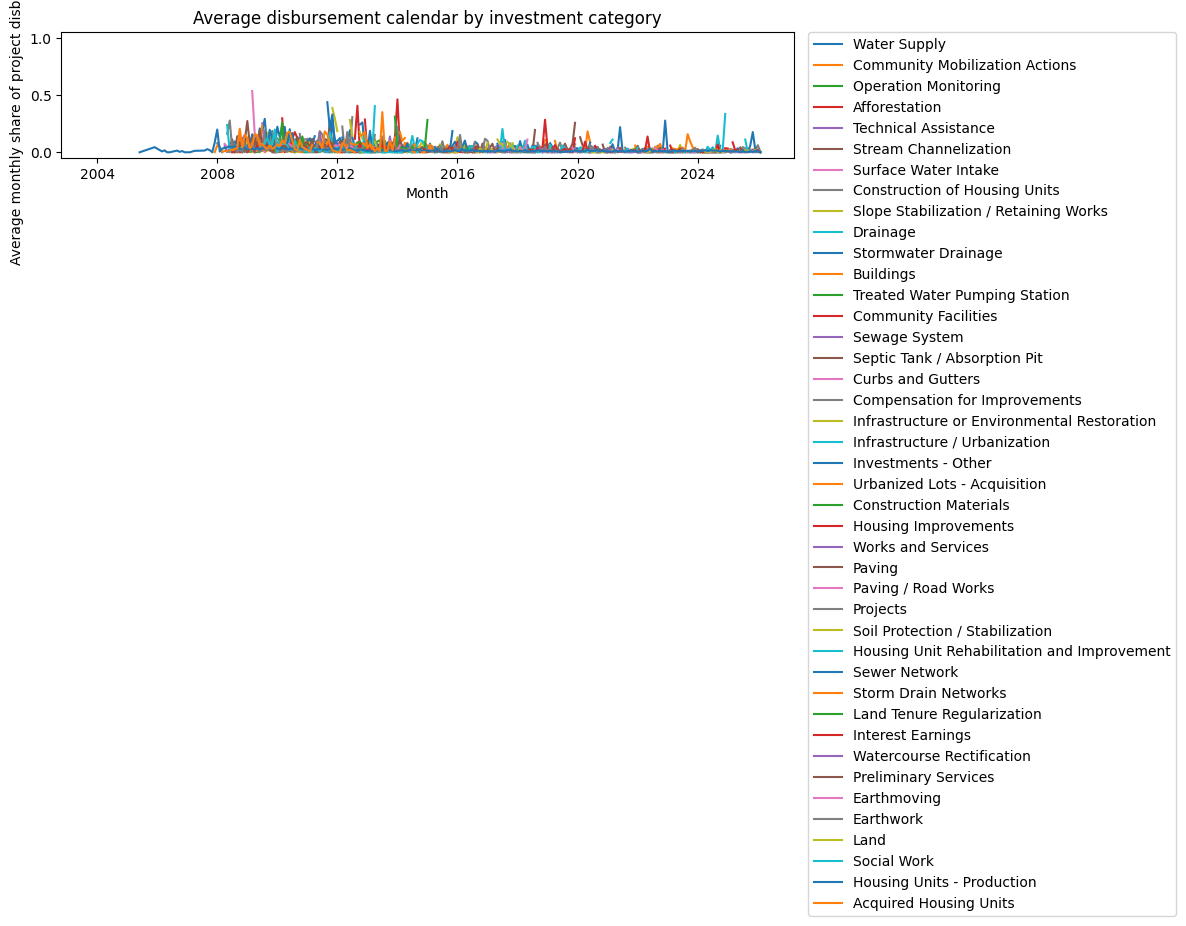

In [116]:


# Plot: uma linha por categoria
plt.figure(figsize=(12, 6))
for col in cal_ts_pivot.columns:
    plt.plot(cal_ts_pivot.index, cal_ts_pivot[col], label=col)

plt.xlabel("Month")
plt.ylabel("Average monthly share of project disbursements")
plt.title("Average disbursement calendar by investment category")

# legenda fora (melhor quando tem muitas linhas)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()


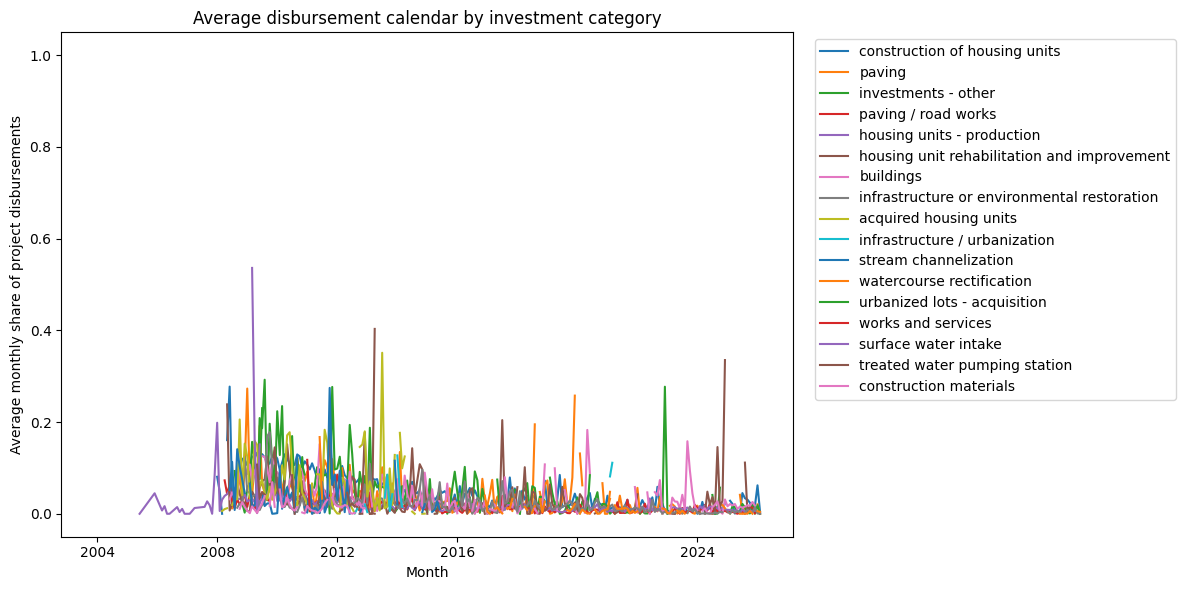

In [109]:
# categorias desejadas (como estão no pivot já traduzido)
selected_cols = [
    "Construction of Housing Units",
    "Paving",
    "Investments - Other",
    "Paving / Road Works",
    "Housing Units - Production",
    "Housing Unit Rehabilitation and Improvement",
    "Buildings",
    "Infrastructure or Environmental Restoration",
    "Acquired Housing Units",
    "Infrastructure / Urbanization",
    "Wastewater Treatment Plant",
    "Stream Channelization",
    "Watercourse Rectification",
    "Urbanized Lots - Acquisition",
    "Works and Services",
    "Surface Water Intake",
    "Treated Water Pumping Station",
    "Construction Materials",
    "Raw Water Adduction",
    "Reservoir Dam",
]

# manter só as colunas que existem no DF (caso alguma tradução tenha pequena diferença)
existing_cols = [c for c in selected_cols if c in cal_ts_pivot.columns]

plot_df = cal_ts_pivot[existing_cols].copy()

# colocar nomes em lowercase
plot_df.columns = plot_df.columns.str.lower()

# plot
plt.figure(figsize=(12, 6))

for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], label=col)

plt.xlabel("Month")
plt.ylabel("Average monthly share of project disbursements")
plt.title("Average disbursement calendar by investment category")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [110]:
plt.savefig("/home/coder/chp2/timeseries_mean_share_by_category.png", dpi=200)
plt.close()

print("✅ Plot salvo em /home/coder/chp2/timeseries_mean_share_by_category.png")

✅ Plot salvo em /home/coder/chp2/timeseries_mean_share_by_category.png


In [134]:
group_map = {

    # 1. Housing Construction
    "CONSTRUCAO DE UNIDADES HABITACIONAIS": "Housing Construction",
    "UNIDADES HABITACIONAIS - PRODUCAO": "Housing Construction",
    "UNIDADES HABITACIONAIS ADQUIRIDAS": "Housing Construction",
    "LOTES URBANIZADOS - AQUISICAO": "Housing Construction",

    # 2. Housing Improvement
    "RECUPERACAO E MELHORIA DE UNID HABIT": "Housing Improvement",
    "MELHORIAS HABITACIONAIS": "Housing Improvement",

    # 3. Urban Infrastructure
    "INFRA-ESTRUTURA/URBANIZACAO": "Urban Infrastructure",
    "INFRA-ESTR OU RECUPERACAO AMBIENTAL": "Urban Infrastructure",
    "OBRAS E SERVICOS": "Urban Infrastructure",
    "PROJETOS": "Urban Infrastructure",
    "SERVICOS PRELIMINARES": "Urban Infrastructure",

    # 4. Roads & Mobility
    "PAVIMENTACAO": "Roads And Mobility",
    "PAVIMENTACAO/OBRAS VIARIAS": "Roads And Mobility",
    "GUIAS E SARJETAS": "Roads And Mobility",

    # 5. Water Supply
    "ABASTECIMENTO DE AGUA": "Water Supply",
    "CAPTACAO SUPERFICIAL": "Water Supply",
    "ELEVATORIA DE AGUA TRATADA": "Water Supply",
    "ADUCAO DE AGUA BRUTA": "Water Supply",
    "BARRAGEM DE ACUMULACAO": "Water Supply",

    # 6. Sanitation
    "ESGOTAMENTO SANITARIO": "Sanitation",
    "REDE DE ESGOTAMENTO SANITARIO": "Sanitation",
    "ESTACAO DE TRATAMENTO DE ESGOTO": "Sanitation",
    "FOSSA/SUMIDOURO": "Sanitation",

    # 7. Drainage & Flood Control
    "DRENAGEM": "Drainage And Flood Control",
    "DRENAGEM DE AGUAS PLUVIAIS": "Drainage And Flood Control",
    "REDES DE GALERIAS PLUVIAS": "Drainage And Flood Control",
    "CANALIZACAO CORREGOS": "Drainage And Flood Control",
    "RETIFICACAO DE CURSOS DE AGUA": "Drainage And Flood Control",

    # 8. Environmental
    "ARBORIZACAO": "Environmental",
    "PROTECAO/CONTENCAO/ESTABILIZACAO DO SOLO": "Environmental",
    "TERRENO": "Environmental",

    # 9. Social & Community
    "TRABALHO SOCIAL": "Social And Community",
    "EQUIPAMENTOS COMUNITARIOS": "Social And Community",
    "ACOES DE MOBILIZACAO DA COMUNIDADE": "Social And Community",
    "ASSISTENCIA TECNICA": "Social And Community",

    # 10. Other / Financial
    "INVESTIMENTOS - OUTROS": "Other And Financial",
    "RENDIMENTOS": "Other And Financial",
}

In [123]:
cal_ts["group"] = cal_ts["dsc_item_investimento"].map(group_map)

# remover categorias não mapeadas (se houver)
cal_ts_grouped = cal_ts.dropna(subset=["group"])

In [124]:
cal_ts_grouped

,dsc_item_investimento,date,mean_share,mean_value,total_value,n_projects,group
0,ABASTECIMENTO DE AGUA,2008-09-01,0.024611,22502551.0,22502551,1,Water Supply
1,ABASTECIMENTO DE AGUA,2008-10-01,0.050527,139435147.0,278870294,2,Water Supply
2,ABASTECIMENTO DE AGUA,2008-11-01,0.009302,17689750.5,70759002,4,Water Supply
3,ABASTECIMENTO DE AGUA,2008-12-01,0.089231,81461602.0,162923204,2,Water Supply
4,ABASTECIMENTO DE AGUA,2009-01-01,0.023629,21604211.0,21604211,1,Water Supply
...,...,...,...,...,...,...,...
4257,UNIDADES HABITACIONAIS ADQUIRIDAS,2014-11-01,0.000107,974102.0,974102,1,Housing Construction
4258,UNIDADES HABITACIONAIS ADQUIRIDAS,2014-12-01,0.000344,1205095.0,1205095,1,Housing Construction
4259,UNIDADES HABITACIONAIS ADQUIRIDAS,2015-03-01,0.007018,348309.0,348309,1,Housing Construction
4260,UNIDADES HABITACIONAIS ADQUIRIDAS,2018-05-01,0.000000,0.0,0,1,Housing Construction


In [125]:
group_ts = (
    cal_ts_grouped
    .groupby(["date", "group"], as_index=False)
    .agg(mean_share=("mean_share", "mean"))
)
group_ts_pivot = (
    group_ts.pivot(index="date", columns="group", values="mean_share")
            .sort_index()
)

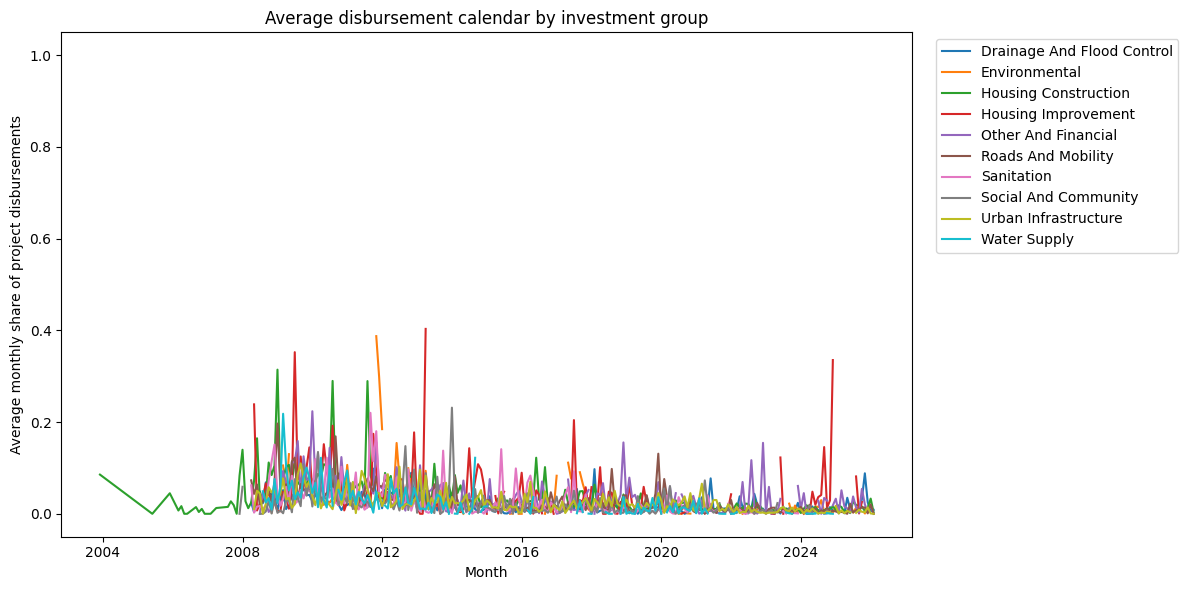

In [126]:
plt.figure(figsize=(12, 6))

for col in group_ts_pivot.columns:
    plt.plot(group_ts_pivot.index, group_ts_pivot[col], label=col)

plt.xlabel("Month")
plt.ylabel("Average monthly share of project disbursements")
plt.title("Average disbursement calendar by investment group")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### other option - more visible

In [ ]:
tab_month = Path("/home/coder/chp2/Tab_Desbloqueado_Mensal.xlsx")
month = pd.read_excel(tab_month, dtype=str)
month.columns = month.columns.str.strip()

proj_cat = df_main_activity[["pt", "dsc_item_investimento"]].copy()
VALUE_COL = "ValorDesbloqueado_VE"   # ou "ValorDesblorqueado_CP" / "ValorDesblorqueado_VI"
MONTH_COL = "MesLIB"
YEAR_COL = "AnoLIB"
PROJ_COL  = "COD PROJETO"

month[PROJ_COL] = month[PROJ_COL].astype(str).str.strip()
month[MONTH_COL] = month[MONTH_COL].astype(str).str.strip()
month[YEAR_COL] = pd.to_numeric(month[YEAR_COL], errors="coerce")
v = month[VALUE_COL].astype(str).str.strip()
v = v.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
month["_valor_num"] = pd.to_numeric(v, errors="coerce").fillna(0.0)

# criar uma coluna de data (YYYY-MM-01) para série temporal
month["date"] = pd.to_datetime(
    dict(year=month[YEAR_COL], month=month[MONTH_COL], day=1),
    errors="coerce"
)

In [39]:
month["COD PROJETO"] = (
    month["COD PROJETO"]
        .astype(str)
        .str.strip()                 # remove espaços nas bordas
        .str.replace(r"\s+", "", regex=True)  # remove TODOS os espaços
)

df_proj["tab26_COD PROJETO"] = (
    df_proj["tab26_COD PROJETO"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
)


In [40]:
def clean_code(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.replace("\u00a0", " ", regex=False)  # NBSP
    s = s.str.strip()
    s = s.str.replace(r"\s+", "", regex=True)                  # remove espaços
    s = s.str.replace(r"\.0$", "", regex=True)                 # remove .0
    s = s.str.replace(r"\D+", "", regex=True)                  # só dígitos
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    return s

month["cod_clean"]  = clean_code(month["COD PROJETO"])
df_proj["cod_clean"] = clean_code(df_proj["tab26_COD PROJETO"])

s_month = set(month["cod_clean"].dropna().unique())
s_proj  = set(df_proj["cod_clean"].dropna().unique())

print("unique month:", len(s_month))
print("unique df_proj:", len(s_proj))
print("intersection:", len(s_month & s_proj))

unique month: 4739
unique df_proj: 1624
intersection: 1368


In [41]:
month1 = month.merge(
    df_proj.drop_duplicates("cod_clean"),
    on="cod_clean",
    how="left",
    suffixes=("", "_dfproj")
)


In [179]:
month1

,COD PROJETO,AnoLIB,MesLIB,ValorDesbloqueado_VE,ValorDesbloqueado_CP,ValorDesbloqueado_VI,_valor_num,date,cod_clean,IBGE-7,tab26_COD PROJETO
0,012865286,2004,12,45000,37053,82053,45000,2004-12-01,012865286,NaN,NaN
1,012865286,2005,05,140314.96,115535,255849.96,14031496,2005-05-01,012865286,NaN,NaN
2,012865286,2005,09,81670.96,67247,148917.96,8167096,2005-09-01,012865286,NaN,NaN
3,012865286,2005,12,105615.96,86964,192579.96,10561596,2005-12-01,012865286,NaN,NaN
4,012865286,2006,08,185935.81,153099,339034.81,18593581,2006-08-01,012865286,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
65529,035148916,2013,11,40275,0,40275,40275,2013-11-01,035148916,NaN,NaN
65530,035148916,2014,08,69471.38,0,69471.38,6947138,2014-08-01,035148916,NaN,NaN
65531,035148916,2014,10,278336.57,0,278336.57,27833657,2014-10-01,035148916,NaN,NaN
65532,035149159,2012,12,88806.75,0,88806.75,8880675,2012-12-01,035149159,NaN,NaN


In [43]:
import pandas as pd
import numpy as np

# -----------------------
# helpers
# -----------------------
def to_num_ptbr(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    s = s.str.replace("\u00a0", " ", regex=False)
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.replace(".", "", regex=False)   # milhar
    s = s.str.replace(",", ".", regex=False)  # decimal
    return pd.to_numeric(s, errors="coerce")

def uf_from_ibge7(s: pd.Series) -> pd.Series:
    # pega 2 primeiros dígitos do IBGE-7 (código UF)
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\D+", "", regex=True)
    s = s.str.zfill(7)
    return s.str[:2]

# -----------------------
# 1) Preparar VE numérico + UF
# -----------------------
month1["ve_num"] = to_num_ptbr(month1["ValorDesbloqueado_VE"]).fillna(0.0)

# se IBGE-7 estiver faltando, UF fica NaN (ok)
month1["uf_ibge"] = np.where(
    month1["IBGE-7"].notna(),
    uf_from_ibge7(month1["IBGE-7"]),
    pd.NA
)

month1["date"] = pd.to_datetime(month1["date"], errors="coerce")

# -----------------------
# 2) TOTAL investido (VE) e série temporal nacional (% do total)
# -----------------------
ve_total = month1["ve_num"].sum()

ts_br = (
    month1.dropna(subset=["date"])
          .groupby("date", as_index=False)["ve_num"]
          .sum()
          .rename(columns={"ve_num": "ve_mes"})
)

ts_br["share_total"] = np.where(ve_total > 0, ts_br["ve_mes"] / ve_total, np.nan)

print("VE total (Brasil):", ve_total)
print(ts_br.head())

# -----------------------
# 3) Série temporal por UF (% do total NACIONAL)
# -----------------------
ts_uf = (
    month1.dropna(subset=["date", "uf_ibge"])
          .groupby(["date", "uf_ibge"], as_index=False)["ve_num"]
          .sum()
          .rename(columns={"ve_num": "ve_mes_uf"})
)

ts_uf["share_total_br"] = np.where(ve_total > 0, ts_uf["ve_mes_uf"] / ve_total, np.nan)

# Pivot: linhas = date, colunas = UF, valores = % do total nacional
ts_uf_pivot = (
    ts_uf.pivot(index="date", columns="uf_ibge", values="share_total_br")
         .fillna(0.0)
         .sort_index()
)

print(ts_uf_pivot.head())

# -----------------------
# (Opcional) % dentro de cada UF (normaliza por total da UF)
# -----------------------
uf_total = ts_uf.groupby("uf_ibge", as_index=False)["ve_mes_uf"].sum().rename(columns={"ve_mes_uf": "ve_total_uf"})
ts_uf2 = ts_uf.merge(uf_total, on="uf_ibge", how="left")
ts_uf2["share_within_uf"] = np.where(ts_uf2["ve_total_uf"] > 0, ts_uf2["ve_mes_uf"] / ts_uf2["ve_total_uf"], np.nan)

ts_uf_within_pivot = (
    ts_uf2.pivot(index="date", columns="uf_ibge", values="share_within_uf")
          .fillna(0.0)
          .sort_index()
)

# agora você tem:
# - ts_br: série Brasil (% do total)
# - ts_uf_pivot: por UF (% do total Brasil)
# - ts_uf_within_pivot: por UF (% do total da própria UF)

VE total (Brasil): 3174580484344
        date    ve_mes   share_total
0 2003-12-01  12607765  3.971474e-06
1 2004-09-01   3125425  9.845159e-07
2 2004-10-01  11047239  3.479905e-06
3 2004-12-01  17844214  5.620968e-06
4 2005-05-01  87269757  2.749017e-05
uf_ibge      11   12   13   14   15   16   17   21   22   23  ...   32   33  \
date                                                          ...             
2003-12-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2005-06-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2005-12-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2006-03-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2006-04-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   

uf_ibge      35   41   42   43        50   51   52   53  
date                                                     
2003-12-01  0.0  0.0  0.0  0.0  0.000004  0.0  0.0  0.0  
2005-06-01  0.0  

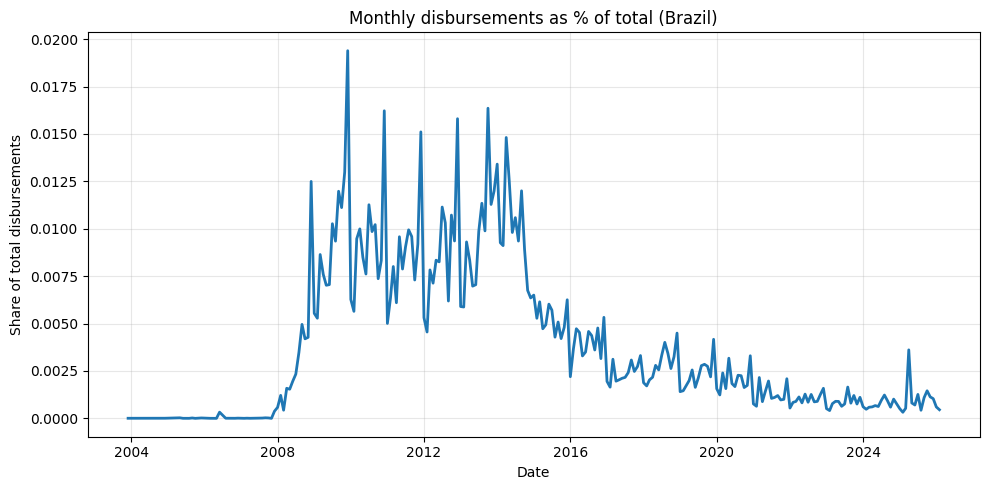

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ts_br["date"], ts_br["share_total"], linewidth=2)

plt.title("Monthly disbursements as % of total (Brazil)")
plt.ylabel("Share of total disbursements")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

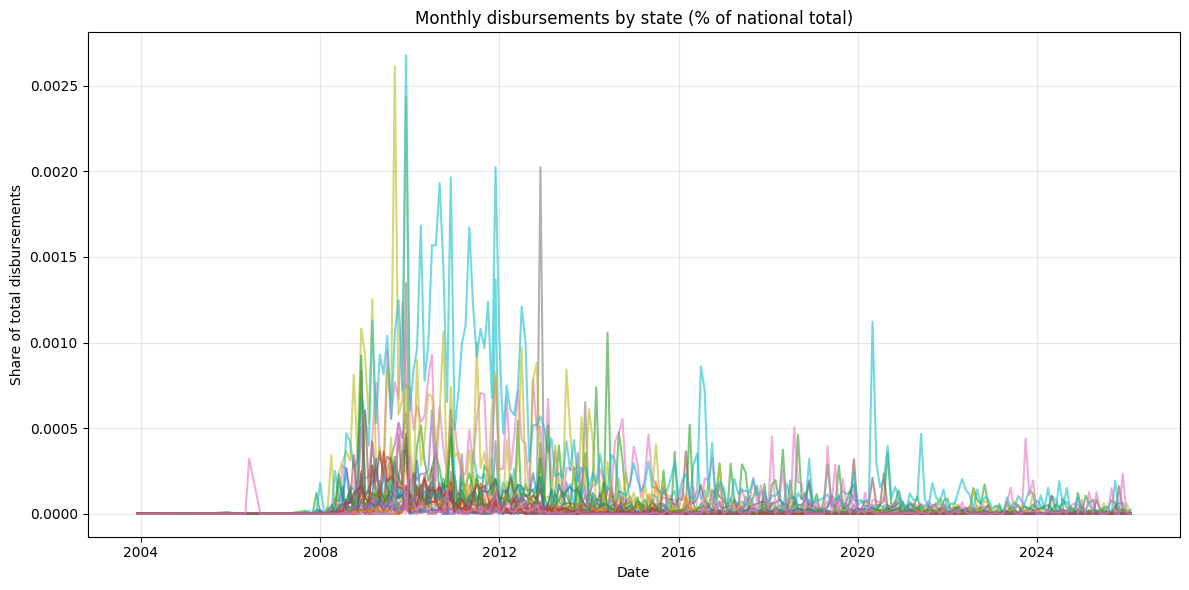

In [45]:
plt.figure(figsize=(12,6))

for col in ts_uf_pivot.columns:
    plt.plot(ts_uf_pivot.index, ts_uf_pivot[col], alpha=0.6)

plt.title("Monthly disbursements by state (% of national total)")
plt.ylabel("Share of total disbursements")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

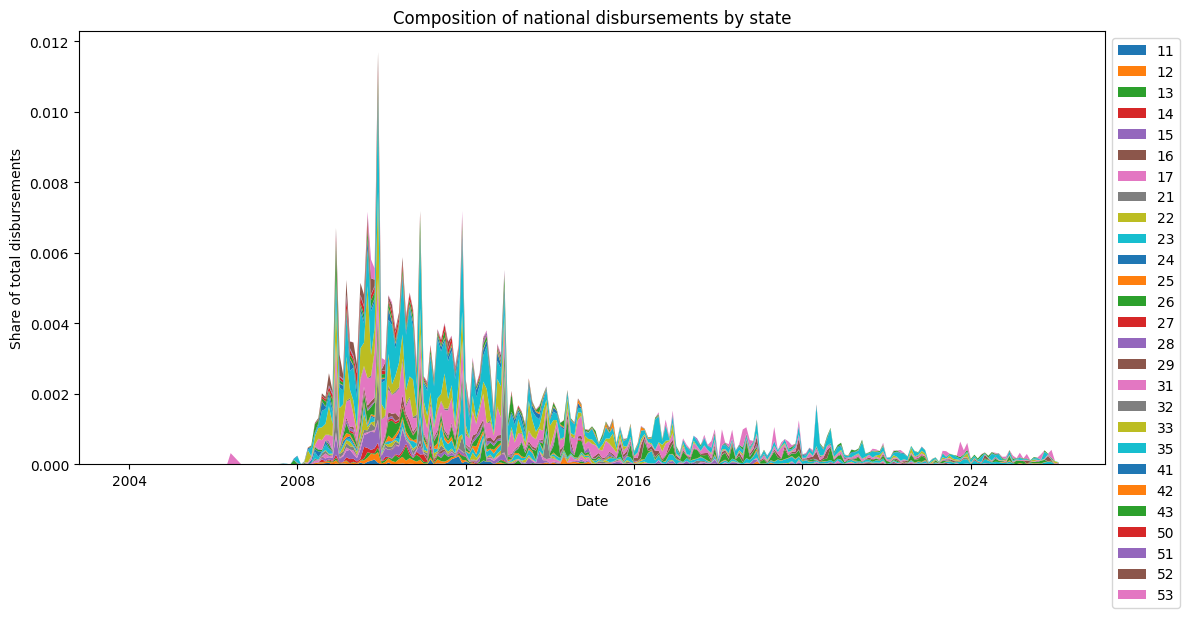

In [46]:
plt.figure(figsize=(12,6))

plt.stackplot(
    ts_uf_pivot.index,
    ts_uf_pivot.T,
    labels=ts_uf_pivot.columns
)

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.title("Composition of national disbursements by state")
plt.ylabel("Share of total disbursements")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [47]:
uf_map = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA", "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB", "26": "PE", "27": "AL", "28": "SE", "29": "BA",
    "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS",
    "50": "MS", "51": "MT", "52": "GO", "53": "DF"
}

In [48]:
ts_plot = ts_uf_pivot.copy()

ts_plot = ts_plot.rename(columns=uf_map)

# Se quiser remover colunas que não mapearam
ts_plot = ts_plot.loc[:, ts_plot.columns.notna()]

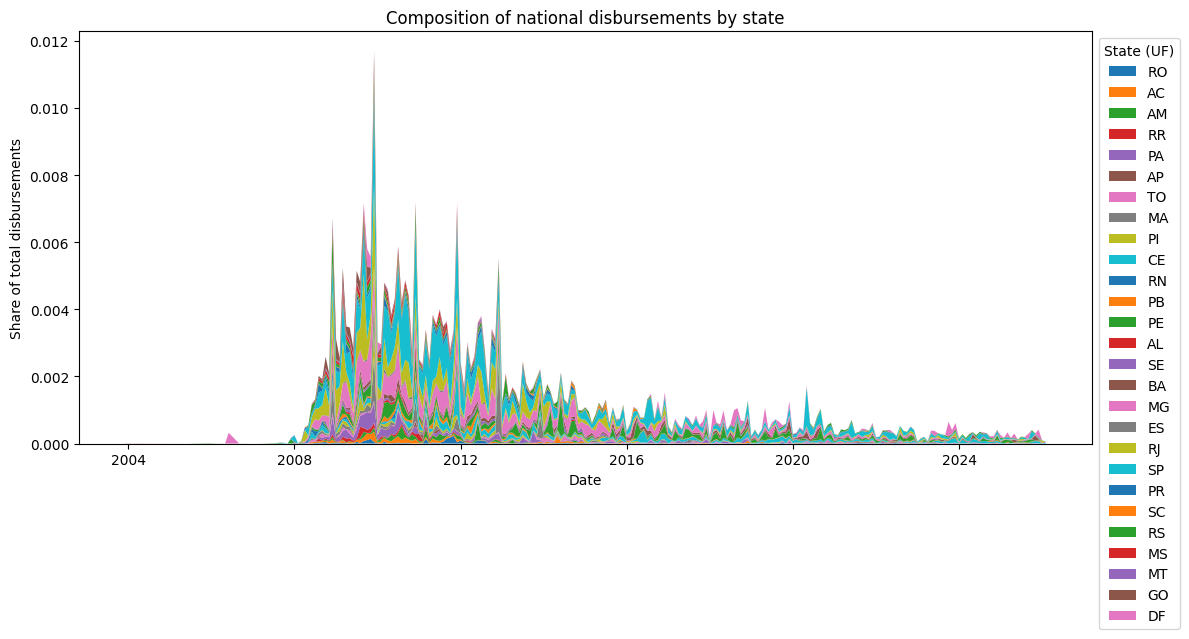

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.stackplot(
    ts_plot.index,
    ts_plot.T,
    labels=ts_plot.columns
)

plt.legend(
    title="State (UF)",
    loc="upper left",
    bbox_to_anchor=(1,1)
)

plt.title("Composition of national disbursements by state")
plt.ylabel("Share of total disbursements")
plt.xlabel("Date")

plt.tight_layout()
plt.show()

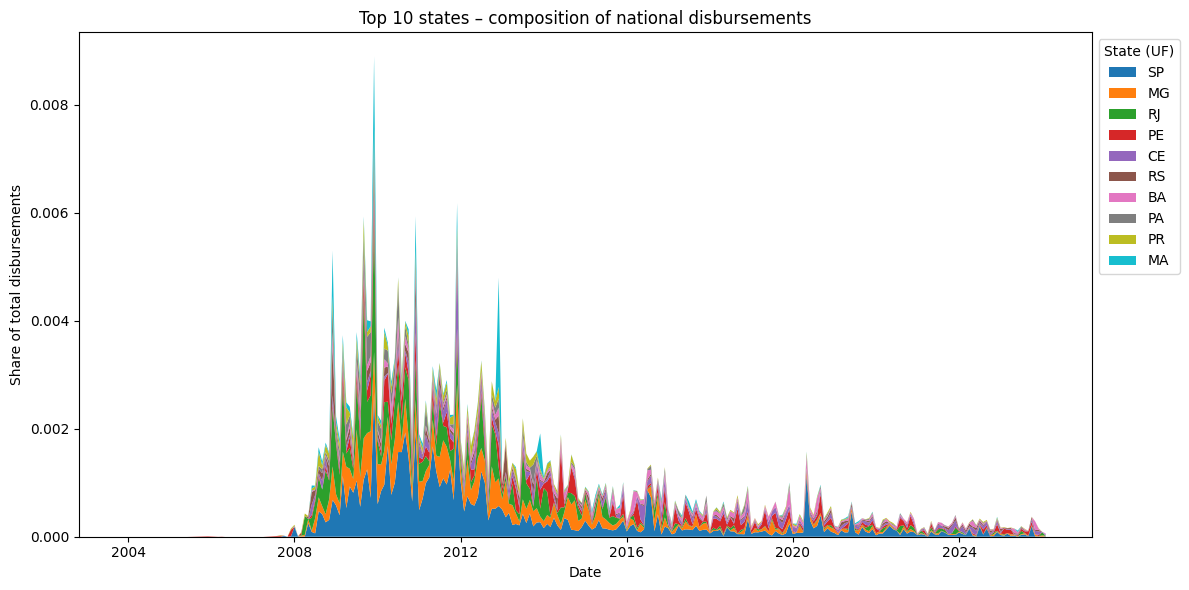

In [50]:
top_ufs = ts_plot.sum().sort_values(ascending=False).head(10).index
ts_plot_top = ts_plot[top_ufs]

plt.figure(figsize=(12,6))
plt.stackplot(
    ts_plot_top.index,
    ts_plot_top.T,
    labels=ts_plot_top.columns
)

plt.legend(title="State (UF)", loc="upper left", bbox_to_anchor=(1,1))
plt.title("Top 10 states – composition of national disbursements")
plt.ylabel("Share of total disbursements")
plt.xlabel("Date")

plt.tight_layout()
plt.show()